In [1]:
import pdfplumber
import re
import pandas as pd
from pathlib import Path

In [2]:
#!pip3 install pdfplumber

In [3]:
import pdfplumber
import re
import pandas as pd
from pathlib import Path

pdf_folder = Path("scorecards")
records = []

for pdf_file in pdf_folder.glob("*.pdf"):
    with pdfplumber.open(pdf_file) as pdf:
        text = "\n".join(page.extract_text() for page in pdf.pages)

        # --- Extract match date/time ---
        date_match = re.search(r"Date\s+(\d{4}-\d{2}-\d{2}),\s+([\d:]+\s+[APM]+ UTC)", text)
        if date_match:
            match_date_str = date_match.group(1)
            match_time_str = date_match.group(2)
            match_time_str = re.sub(r'\s*[APM]+\s+UTC', ' UTC', match_time_str)
            match_datetime = pd.to_datetime(f"{match_date_str} {match_time_str}")
        else:
            match_datetime = None

        # --- Find all Warsaw Hussars innings headers (1st + 2nd + declared) ---
        headers = list(re.finditer(
            r"(Warsaw Hussars)\s+\d+/\d+d?\s+\([\d.]+\s*Ov\)\s+\((\d+(?:st|nd))\s+Innings\)",
            text
        ))
        # if len(headers)<2:
        #     continue
        for i, hdr in enumerate(headers):
            team_name = hdr.group(1)
            innings_label = hdr.group(2)  # e.g. "1st" or "2nd"

            start = hdr.start()  # start at header
            end = headers[i+1].start() if i + 1 < len(headers) else len(text)
            innings_text = text[start:end]

            # Stop parsing at "Extras" or "Total"
            stop_match = re.search(r"Extras:|Total:", innings_text)
            if stop_match:
                innings_text = innings_text[:stop_match.start()]

            # --- Parse batting lines ---
            for line in innings_text.splitlines():
                line = line.strip()
                #print(line)
                # Skip lines that are new innings or other team headers
                if re.match(r".+\s+\d+/\d+d?\s+\([\d.]+\s*Ov\)\s+\(\d+(?:st|nd)\s+Innings\)", line) and "Warsaw Hussars" not in line:
                    break

                # Batting line regex
                pattern = re.compile(
                        r"^(\d+)\s+"                        # Position
                        r"([A-Za-z\s&'.()’-]+?)\s+"         # Batsman Name
                        r"\(.*?\)\s+"                        # Handedness (RHB/LHB)
                        r"(.+?)\s+"                          # Status (can contain run outs, multiple names, etc.)
                        r"(\d+)\s+"                          # Runs
                        r"(\d+)\s+"                          # Balls
                        r"(\d+)\s+"                          # M (minutes or ignored)
                        r"(\d+)\s+"                          # Fours
                        r"(\d+)\s+"                          # Sixes
                        r"([\d.]+)$"                         # Strike Rate
                    )

                m = pattern.match(line)
                if m:
                    
                    pos, name, status, runs, balls, _, fours, sixes, sr = m.groups()
                    records.append({
                        "file": pdf_file.name,
                        "team": team_name,
                        "innings": innings_label,       # ✅ 1st or 2nd innings
                        "batsman": name.strip(),
                        "status": status.strip(),
                        "runs": int(runs),
                        "balls": int(balls),
                        "fours": int(fours),
                        "sixes": int(sixes),
                        "sr": float(sr),
                        "position": int(pos),
                        "match_date": match_datetime
                    })

# ✅ Build the full summary
if not records:
    print("⚠️ No Warsaw Hussars innings found.")
else:
    df = pd.DataFrame(records)
    df = df.sort_values(by="match_date")

    # Mark outs
    df["out"] = df["status"].apply(lambda s: 0 if "not out" in s.lower() else 1)

    # Aggregate by batsman
    summary = (
        df.groupby("batsman")
          .agg(
              innings=("file", "count"),
              runs=("runs", "sum"),
              balls=("balls", "sum"),
              fours=("fours", "sum"),
              sixes=("sixes", "sum"),
              outs=("out", "sum"),
              avg_position=("position", "mean")
          )
          .reset_index()
    )

    # Derived stats
    summary["strike_rate"] = (summary["runs"] / summary["balls"]) * 100
    summary["average"] = summary.apply(
        lambda r: r["runs"] / r["outs"] if r["outs"] > 0 else None, axis=1
    )

    summary = summary.round({
        "avg_position": 2,
        "strike_rate": 2,
        "average": 2
    })

    summary = summary.sort_values(by="runs", ascending=False)

    # Save and print
    print(summary)
    summary.to_csv("warsaw_hussars_full_batting_summary.csv", index=False)

    # # ===== Extract individual scores =====
    # def get_batsman_scores(df, batsman_name):
    #     batsman_df = df[df["batsman"].str.lower() == batsman_name.lower()].sort_values(by="match_date")
    #     if batsman_df.empty:
    #         print(f"⚠️ No records found for '{batsman_name}'")
    #         return []
    #     return batsman_df[["match_date","runs", "balls", "fours", "sixes", "sr", "status"]].to_dict(orient="records")


    # # Example usage
    # batsman_name = input("Enter batsman name: ").strip()
    # scores = get_batsman_scores(df, batsman_name)
    # if scores:
    #     print(f"\nScores for {batsman_name}:")
    #     for i, innings in enumerate(scores, 1):
    #         print(f"Innings {i}: {innings}")



                 batsman  innings  runs  balls  fours  sixes  outs  \
13                  Neel       19   331    304     32     12    19   
21         Utkarsh Bhatt       13   310    240     35      4    11   
10       Matthew Keating       17   260    345     19      2    15   
11   Michal OstykNarbutt       16   147    178     14      2    14   
19     Siddhesh Mervekar       12   145    149      9      0    11   
9            Kurt DSouza       10   145    170     13      0    10   
22             Wilfred R       16   129    149      7      2    14   
12    Nazroon Najumudeen       14   127    180      6      0    13   
16           Sameer Gaur       15   103    147      8      1    11   
2                   Figo        9    90     88      9      1     5   
17        Shankar Kartha        9    41     59      2      0     8   
15  Prabhat Singh Gusain        4    35     34      3      1     2   
5       Jakub Blazejczyk        8    24     74      0      0     6   
3    Harshit Kumar S

In [4]:
summary["average"] = summary.apply(
    lambda r: r["runs"] / r["outs"] if r["outs"] > 0 else r["runs"],
    axis=1
)

# Round to 2 decimal places
summary["average"] = summary["average"].round(2)

In [5]:
#summary.reset_index(drop=True)
summary.reset_index(drop=True).to_csv("warsaw_hussars_full_batting_summary.csv")

In [6]:
summary

,batsman,innings,runs,balls,fours,sixes,outs,avg_position,strike_rate,average
13,Neel,19,331,304,32,12,19,2.58,108.88,17.42
21,Utkarsh Bhatt,13,310,240,35,4,11,2.77,129.17,28.18
10,Matthew Keating,17,260,345,19,2,15,2.59,75.36,17.33
11,Michal OstykNarbutt,16,147,178,14,2,14,5.62,82.58,10.50
19,Siddhesh Mervekar,12,145,149,9,0,11,5.67,97.32,13.18
9,Kurt DSouza,10,145,170,13,0,10,4.60,85.29,14.50
22,Wilfred R,16,129,149,7,2,14,6.88,86.58,9.21
12,Nazroon Najumudeen,14,127,180,6,0,13,5.00,70.56,9.77
16,Sameer Gaur,15,103,147,8,1,11,6.33,70.07,9.36
2,Figo,9,90,88,9,1,5,8.56,102.27,18.00


In [7]:
print(innings_text)

Warsaw Hussars 136/6 (18.1 Ov) (1st Innings) Matthew Keating (Warsaw Hussars)
No Batsman Status R B M 4s 6s SR
1 Neel (RHB) c Sanjay Kumar b Arun Venkatarajan 9 12 9 1 0 75.00
2 Utkarsh Bhatt (RHB) not out 70 40 89 10 2 175.00
3 Matthew Keating (c & wk) (RHB) c Akhil Batham b Amal Jacob 10 14 21 0 0 71.43
4 Prabhat Singh Gusain (LHB) c Shafaqat Iqbal b Akhil Batham 2 4 7 0 0 50.00
5 Michal OstykNarbutt (RHB) lbw b Shafaqat Iqbal 12 16 24 0 1 75.00
6 Siddhesh Mervekar (RHB) lbw b Nilesh Jain 17 12 12 1 0 141.67
7 Wilfred R (RHB) c Shaikh Mohd Kashif b Shafaqat Iqbal 5 8 10 0 0 62.50
8 Harshit Kumar Singh (RHB) not out 2 3 2 0 0 66.67



In [8]:
summary.sort_values(by="avg_position", ascending=True)[['batsman', 'avg_position', 'innings']].reset_index(drop=True)

,batsman,avg_position,innings
0,Brian Paszkowiak,1.00,1
1,Neel,2.58,19
2,Matthew Keating,2.59,17
3,Utkarsh Bhatt,2.77,13
4,Ashwini Rajput,3.50,2
5,Prabhat Singh Gusain,4.50,4
6,Kurt DSouza,4.60,10
7,Shankar Kartha,4.67,9
8,Nazroon Najumudeen,5.00,14
9,Jakub Zagozdzon,5.00,1


In [16]:
# --- Calculate MVP Score ---
summary["MVP_score"] = (
    (summary["runs"] * 0.5) +
    (summary["average"].fillna(0) * 1.0) +
    (summary["strike_rate"].fillna(0) * 0.2) +
    (summary["innings"] * 2)
)

# Sort by MVP
summary = summary.sort_values(by="runs", ascending=False).reset_index(drop=True)
summary

,batsman,innings,runs,balls,fours,sixes,outs,avg_position,strike_rate,average,MVP_score
0,Neel,19,331,304,32,12,19,2.58,108.88,17.42,242.696
1,Utkarsh Bhatt,13,310,240,35,4,11,2.77,129.17,28.18,235.014
2,Matthew Keating,17,260,345,19,2,15,2.59,75.36,17.33,196.402
3,Michal OstykNarbutt,16,147,178,14,2,14,5.62,82.58,10.50,132.516
4,Siddhesh Mervekar,12,145,149,9,0,11,5.67,97.32,13.18,129.144
5,Kurt DSouza,10,145,170,13,0,10,4.60,85.29,14.50,124.058
6,Wilfred R,16,129,149,7,2,14,6.88,86.58,9.21,123.026
7,Nazroon Najumudeen,14,127,180,6,0,13,5.00,70.56,9.77,115.382
8,Sameer Gaur,15,103,147,8,1,11,6.33,70.07,9.36,104.874
9,Figo,9,90,88,9,1,5,8.56,102.27,18.00,101.454


In [41]:
# ===== Extract individual scores =====
def get_batsman_scores(df, batsman_name):
    batsman_df = df[df["batsman"].str.lower() == batsman_name.lower()].sort_values(by="match_date")
    if batsman_df.empty:
        print(f"⚠️ No records found for '{batsman_name}'")
        return []
    return batsman_df[["match_date","runs", "balls", "fours", "sixes", "sr", "status"]].to_dict(orient="records")

In [42]:
# Example usage
batsman_name = input("Enter batsman name: ").strip()
scores = get_batsman_scores(df, batsman_name)
if scores:
    print(f"\nScores for {batsman_name}:")
    for i, innings in enumerate(scores, 1):
        print(f"Innings {i}: {innings}")

scores_tmp = pd.DataFrame(scores)
scores_tmp['match_date'] = pd.to_datetime(scores_tmp['match_date'])
scores_tmp = scores_tmp.sort_values('match_date').reset_index(drop=True)

# 1️⃣ Flag whether the batsman was out or not
scores_tmp['is_out'] = ~scores_tmp['status'].str.lower().str.contains('not out')

# 2️⃣ Compute cumulative totals
scores_tmp['cum_runs'] = scores_tmp['runs'].cumsum()
scores_tmp['cum_outs'] = scores_tmp['is_out'].cumsum()

# 3️⃣ Calculate batting average up to that match
scores_tmp['batting_avg_till_match'] = scores_tmp['cum_runs'] / scores_tmp['cum_outs'].replace(0, int(scores_tmp['cum_runs'][0]))

# (Optional) also calculate cumulative strike rate till each match
scores_tmp['cum_balls'] = scores_tmp['balls'].cumsum()
scores_tmp['strike_rate_till_match'] = (scores_tmp['cum_runs'] / scores_tmp['cum_balls']) * 100
scores_tmp

Enter batsman name:  Michal OstykNarbutt



Scores for Michal OstykNarbutt:
Innings 1: {'match_date': Timestamp('2025-04-06 11:45:00+0000', tz='UTC'), 'runs': 0, 'balls': 1, 'fours': 0, 'sixes': 0, 'sr': 0.0, 'status': 'b Chandraprakash Rai'}
Innings 2: {'match_date': Timestamp('2025-05-01 09:30:00+0000', tz='UTC'), 'runs': 0, 'balls': 2, 'fours': 0, 'sixes': 0, 'sr': 0.0, 'status': 'lbw b Ragavendran Rangasamy'}
Innings 3: {'match_date': Timestamp('2025-05-17 06:22:00+0000', tz='UTC'), 'runs': 12, 'balls': 17, 'fours': 1, 'sixes': 0, 'sr': 70.59, 'status': 'b Saurabh Sharma07'}
Innings 4: {'match_date': Timestamp('2025-05-24 06:00:00+0000', tz='UTC'), 'runs': 11, 'balls': 32, 'fours': 1, 'sixes': 0, 'sr': 34.38, 'status': 'b Boopathy Raja'}
Innings 5: {'match_date': Timestamp('2025-06-07 11:40:00+0000', tz='UTC'), 'runs': 51, 'balls': 38, 'fours': 5, 'sixes': 0, 'sr': 134.21, 'status': 'not out'}
Innings 6: {'match_date': Timestamp('2025-06-15 11:40:00+0000', tz='UTC'), 'runs': 22, 'balls': 25, 'fours': 3, 'sixes': 0, 'sr': 88

,match_date,runs,balls,fours,sixes,sr,status,is_out,cum_runs,cum_outs,batting_avg_till_match,cum_balls,strike_rate_till_match
0,2025-04-06 11:45:00+00:00,0,1,0,0,0.00,b Chandraprakash Rai,True,0,1,0.000000,1,0.000000
1,2025-05-01 09:30:00+00:00,0,2,0,0,0.00,lbw b Ragavendran Rangasamy,True,0,2,0.000000,3,0.000000
2,2025-05-17 06:22:00+00:00,12,17,1,0,70.59,b Saurabh Sharma07,True,12,3,4.000000,20,60.000000
3,2025-05-24 06:00:00+00:00,11,32,1,0,34.38,b Boopathy Raja,True,23,4,5.750000,52,44.230769
4,2025-06-07 11:40:00+00:00,51,38,5,0,134.21,not out,False,74,4,18.500000,90,82.222222
5,2025-06-15 11:40:00+00:00,22,25,3,0,88.00,c Ragavendran Rangasamy b Gokul Gopalakrishnan,True,96,5,19.200000,115,83.478261
6,2025-06-28 10:30:00+00:00,4,11,0,0,36.36,c pasindu vindula b Saqib Ali,True,100,6,16.666667,126,79.365079
7,2025-06-29 14:08:00+00:00,6,4,1,0,150.00,b Chirag Sonawane,True,106,7,15.142857,130,81.538462
8,2025-08-03 13:27:00+00:00,1,4,0,0,25.00,b SYED HUSSAIN,True,107,8,13.375000,134,79.850746
9,2025-08-10 06:30:00+00:00,5,5,1,0,100.00,c Sadiq Vali b Siddharth Gupta,True,112,9,12.444444,139,80.575540


In [43]:
scores_tmp.to_csv()

',match_date,runs,balls,fours,sixes,sr,status,is_out,cum_runs,cum_outs,batting_avg_till_match,cum_balls,strike_rate_till_match\n0,2025-04-06 11:45:00+00:00,0,1,0,0,0.0,b Chandraprakash Rai,True,0,1,0.0,1,0.0\n1,2025-05-01 09:30:00+00:00,0,2,0,0,0.0,lbw b Ragavendran Rangasamy,True,0,2,0.0,3,0.0\n2,2025-05-17 06:22:00+00:00,12,17,1,0,70.59,b Saurabh Sharma07,True,12,3,4.0,20,60.0\n3,2025-05-24 06:00:00+00:00,11,32,1,0,34.38,b Boopathy Raja,True,23,4,5.75,52,44.230769230769226\n4,2025-06-07 11:40:00+00:00,51,38,5,0,134.21,not out,False,74,4,18.5,90,82.22222222222221\n5,2025-06-15 11:40:00+00:00,22,25,3,0,88.0,c Ragavendran Rangasamy b Gokul Gopalakrishnan,True,96,5,19.2,115,83.47826086956522\n6,2025-06-28 10:30:00+00:00,4,11,0,0,36.36,c pasindu vindula b Saqib Ali,True,100,6,16.666666666666668,126,79.36507936507937\n7,2025-06-29 14:08:00+00:00,6,4,1,0,150.0,b Chirag Sonawane,True,106,7,15.142857142857142,130,81.53846153846153\n8,2025-08-03 13:27:00+00:00,1,4,0,0,25.0,b SYED HUSSAIN,True,

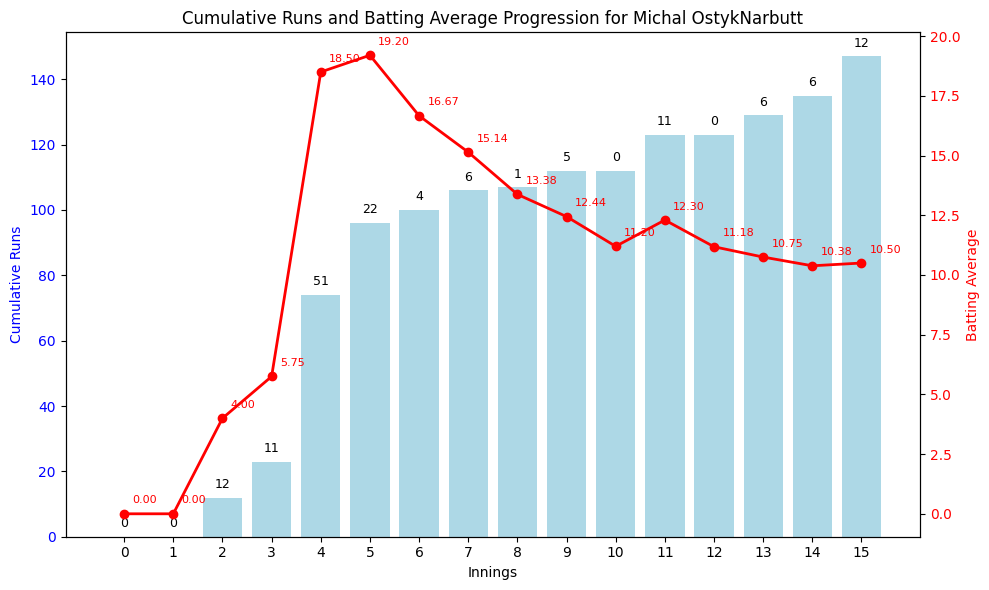

In [44]:
import matplotlib.pyplot as plt

# Ensure cumulative runs exist
scores_tmp['cum_runs'] = scores_tmp['runs'].cumsum()

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Bar chart for cumulative runs ---
bars = ax1.bar(
    range(len(scores_tmp)),
    scores_tmp['cum_runs'],
    color='lightblue',
    label='Cumulative Runs'
)

# Add run labels above each bar
for bar, runs in zip(bars, scores_tmp['runs']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{runs}",
        ha='center', va='bottom',
        fontsize=9, color='black'
    )

# Axis labels for cumulative runs
ax1.set_xlabel('Innings')
ax1.set_ylabel('Cumulative Runs', color='blue')
ax1.set_xticks(range(len(scores_tmp)))
ax1.tick_params(axis='y', labelcolor='blue')

# --- Second axis for batting average ---
ax2 = ax1.twinx()
ax2.plot(
    range(len(scores_tmp)),
    scores_tmp['batting_avg_till_match'],
    color='red',
    marker='o',
    linewidth=2,
    label='Batting Average (Till Match)'
)
ax2.set_ylabel('Batting Average', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Add average labels at each red dot (with offset) ---
for i, avg in enumerate(scores_tmp['batting_avg_till_match']):
    if pd.notna(avg):
        ax2.annotate(
            f"{avg:.2f}",          # text
            (i, avg),              # point (x, y)
            textcoords='offset points',
            xytext=(6, 6),         # offset (x, y) in points
            ha='left', va='bottom',
            color='red',
            fontsize=8
        )

# Title and layout
plt.title(f'Cumulative Runs and Batting Average Progression for {batsman_name}')
fig.tight_layout()
plt.show()
